## 0. Setup


In [118]:
# Enable autoreload so edits to modules are picked up without restarting the kernel
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import torch

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [120]:
# Project root import helper
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "experiment").exists() and (candidate / "fdd_system").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
print("Root:", ROOT)


Root: /home/btanady/fourth_year/cpen491


## 1. Prepare training data


In [121]:
from fdd_system.ML.common.config import OperatingCondition
from experiment.utils import prepare_training_data
from sklearn.model_selection import train_test_split
from pathlib import Path
import os

DATA_PATH = ROOT / "experiment" / "data_14"
REMOVE_FIRST_SECOND = 2

# Split ratios (must sum to 1.0)
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

if abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) > 1e-6:
    raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must sum to 1.0")

# Derived split sizes
TEST_SIZE = TEST_RATIO
VAL_SIZE_IN_TRAINVAL = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

normal_path = DATA_PATH / "normal"
blocked_path = DATA_PATH / "blocked"
interfere_path = DATA_PATH / "interfere"

INTERFERE_LABEL = OperatingCondition.BLADE_ISSUE.value

NORMAL_FILES = sorted([os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(".csv")])
BLOCKED_FILES = sorted([os.path.join(blocked_path, f) for f in os.listdir(blocked_path) if f.endswith(".csv")])
INTERFERE_FILES = (
    sorted([os.path.join(interfere_path, f) for f in os.listdir(interfere_path) if f.endswith(".csv")])
    if interfere_path.exists() else []
)

norm_trainval, norm_test = train_test_split(NORMAL_FILES, test_size=TEST_SIZE, shuffle=True, random_state=SEED)
blk_trainval, blk_test = train_test_split(BLOCKED_FILES, test_size=TEST_SIZE, shuffle=True, random_state=SEED)

if INTERFERE_FILES:
    int_trainval, int_test = train_test_split(INTERFERE_FILES, test_size=TEST_SIZE, shuffle=True, random_state=SEED)
    int_train, int_val = train_test_split(int_trainval, test_size=TEST_SIZE, shuffle=True, random_state=SEED)
else:
    int_train, int_val, int_test = [], [], []

norm_train, norm_val = train_test_split(norm_trainval, test_size=TEST_SIZE, shuffle=True, random_state=SEED)
blk_train, blk_val = train_test_split(blk_trainval, test_size=TEST_SIZE, shuffle=True, random_state=SEED)

train_files = {
    OperatingCondition.NORMAL.value: norm_train,
    OperatingCondition.BLOCKED_AIRFLOW.value: blk_train,
    INTERFERE_LABEL: int_train,
}
val_files = {
    OperatingCondition.NORMAL.value: norm_val,
    OperatingCondition.BLOCKED_AIRFLOW.value: blk_val,
    INTERFERE_LABEL: int_val,
}
test_files = {
    OperatingCondition.NORMAL.value: norm_test,
    OperatingCondition.BLOCKED_AIRFLOW.value: blk_test,
    INTERFERE_LABEL: int_test,
}

train_data = prepare_training_data(train_files, True, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND)
val_data = prepare_training_data(val_files, True, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND)
test_data = prepare_training_data(test_files, False, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND)

print(f"windows: train={len(train_data)}, val={len(val_data)}, test={len(test_data)}")


windows: train=492, val=123, test=246


## 2. Preprocessing


In [122]:
from fdd_system.ML.common.preprocessor import *

# pre = DummyPreprocessor()
# pre = BasicPreprocessor()
# pre = StandardZNormal()
pre = RMSNormalization()

train_pre = pre.preprocess(train_data)
val_pre = pre.preprocess(val_data)
test_pre = pre.preprocess(test_data)

print(f"kept windows: train={len(train_pre)}, val={len(val_pre)}, test={len(test_pre)}")


kept windows: train=492, val=123, test=246


## Noise augmentation
Add adjustable Gaussian noise to accelerometer windows to improve robustness to sensor noise/mounting vibration.


In [123]:
import numpy as np
from fdd_system.ML.common.config import RawAccWindow

NOISE_STD_G = 0.002
NOISE_COPIES = 0

def _with_noise(win: RawAccWindow, noise_std: float) -> RawAccWindow:
    ax = win.acc_x + np.random.normal(0, noise_std, size=win.acc_x.shape)
    ay = win.acc_y + np.random.normal(0, noise_std, size=win.acc_y.shape)
    az = win.acc_z + np.random.normal(0, noise_std, size=win.acc_z.shape)
    return RawAccWindow(acc_x=ax, acc_y=ay, acc_z=az, label=win.label, device_id=win.device_id)

if NOISE_STD_G > 0 and NOISE_COPIES > 0:
    noisy_windows = []
    for _ in range(NOISE_COPIES):
        noisy_windows.extend([_with_noise(w, NOISE_STD_G) for w in train_pre])
    train_pre = train_pre + noisy_windows
    print(f"Augmented train windows with Gaussian noise: +{len(noisy_windows)} samples")
else:
    print("Noise augmentation disabled")


Noise augmentation disabled


## 3. Build tensors for 1D CNN


In [124]:
import numpy as np
from collections import Counter

def stack_windows(windows, target_len=None):
    if len(windows) == 0:
        raise ValueError("No windows found.")

    if target_len is None:
        target_len = min(
            min(len(w.acc_x), len(w.acc_y), len(w.acc_z))
            for w in windows
        )

    X = np.empty((len(windows), 3, target_len), dtype=np.float32)
    y_raw = np.empty((len(windows),), dtype=np.int64)

    for i, w in enumerate(windows):
        X[i, 0] = np.asarray(w.acc_x, dtype=np.float32)[:target_len]
        X[i, 1] = np.asarray(w.acc_y, dtype=np.float32)[:target_len]
        X[i, 2] = np.asarray(w.acc_z, dtype=np.float32)[:target_len]
        y_raw[i] = int(w.label)

    return X, y_raw, target_len

X_train_raw, y_train_raw, target_len = stack_windows(train_pre)
X_val_raw, y_val_raw, _ = stack_windows(val_pre, target_len=target_len)
X_test_raw, y_test_raw, _ = stack_windows(test_pre, target_len=target_len)

# Train-set normalization stats only
mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-6

X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std
X_test = (X_test_raw - mean) / std

# Label encoding (handles missing optional classes safely)
all_labels = sorted(set(y_train_raw.tolist()) | set(y_val_raw.tolist()) | set(y_test_raw.tolist()))
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = np.array([label_to_idx[int(y)] for y in y_train_raw], dtype=np.int64)
y_val = np.array([label_to_idx[int(y)] for y in y_val_raw], dtype=np.int64)
y_test = np.array([label_to_idx[int(y)] for y in y_test_raw], dtype=np.int64)

print("input shape (N, C, L):", X_train.shape)
print("class mapping:", label_to_idx)
print("train class counts:", Counter(y_train_raw.tolist()))


input shape (N, C, L): (492, 3, 1000)
class mapping: {0: 0, 1: 1, 2: 2}
train class counts: Counter({0: 164, 2: 164, 1: 164})


In [125]:
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


## 4. Train 1D CNN


In [126]:
import copy
import os
from pathlib import Path
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score

class Fan1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def reset_stage2_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_stage2_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(label_to_idx)
model = Fan1DCNN(n_classes=num_classes).to(device)

counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = counts.sum() / np.maximum(counts * num_classes, 1.0)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

EPOCHS = 40
EARLY_STOP_PATIENCE = 8

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    all_pred = []
    all_true = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * yb.size(0)

        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(yb.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc, y_true, y_pred


def train_one_epoch(loader):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)

    return total_loss / len(loader.dataset)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_state = None
best_val_loss = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(train_loader)
    val_loss, val_acc, _, _ = evaluate(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"epoch={epoch:02d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= EARLY_STOP_PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is None:
    raise RuntimeError("Training did not produce a valid model state.")

model.load_state_dict(best_state)

os.makedirs("weights", exist_ok=True)
MODEL_SAVE_PATH = Path("weights/model_best_cnn1d.pt")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "mean": mean.astype(np.float32),
        "std": std.astype(np.float32),
        "window_len": int(target_len),
    },
    MODEL_SAVE_PATH,
)
print(f"Saved best 1D CNN to {MODEL_SAVE_PATH}")


epoch=01 train_loss=0.8325 val_loss=1.0474 val_acc=0.3333 lr=1.00e-03
epoch=02 train_loss=0.5542 val_loss=0.9441 val_acc=0.6260 lr=1.00e-03
epoch=03 train_loss=0.4612 val_loss=0.8002 val_acc=0.6341 lr=1.00e-03
epoch=04 train_loss=0.3586 val_loss=1.0571 val_acc=0.3659 lr=1.00e-03
epoch=05 train_loss=0.2470 val_loss=0.9826 val_acc=0.5854 lr=1.00e-03
epoch=06 train_loss=0.1551 val_loss=1.6600 val_acc=0.3740 lr=1.00e-03
epoch=07 train_loss=0.0978 val_loss=2.5916 val_acc=0.3577 lr=5.00e-04
epoch=08 train_loss=0.1020 val_loss=0.5718 val_acc=0.8618 lr=5.00e-04
epoch=09 train_loss=0.0990 val_loss=0.3827 val_acc=0.8211 lr=5.00e-04
epoch=10 train_loss=0.0572 val_loss=0.1356 val_acc=0.9593 lr=5.00e-04
epoch=11 train_loss=0.0377 val_loss=0.1766 val_acc=0.9350 lr=5.00e-04
epoch=12 train_loss=0.0306 val_loss=0.2686 val_acc=0.9268 lr=5.00e-04
epoch=13 train_loss=0.0302 val_loss=0.3169 val_acc=0.8699 lr=5.00e-04
epoch=14 train_loss=0.0282 val_loss=0.4357 val_acc=0.8780 lr=2.50e-04
epoch=15 train_loss=

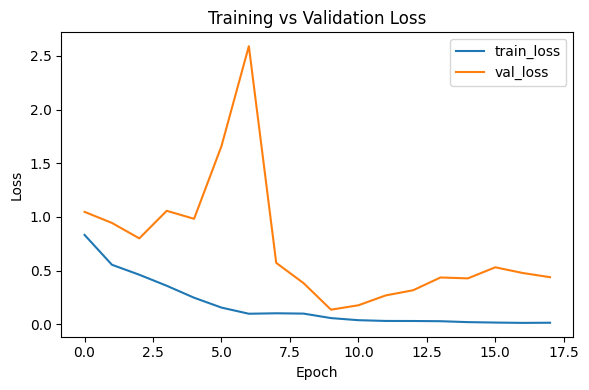

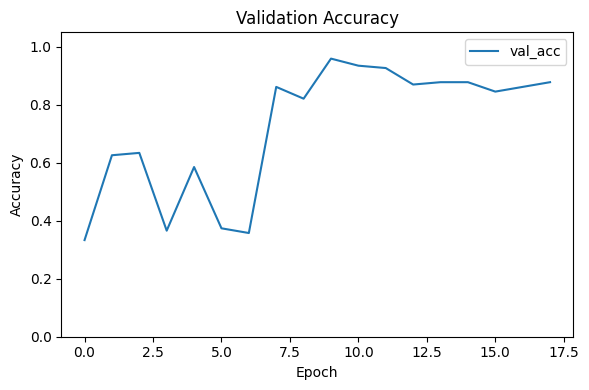

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Evaluate on test set


1D CNN test accuracy (majority vote, NUM_SAMPLES=1): 0.919
1D CNN test FP rate (NORMAL misclassified as BLOCKED): 0.079

              precision    recall  f1-score   support

      NORMAL       0.91      0.84      0.87        82
     BLOCKED       0.85      0.91      0.88        82
   INTERFERE       1.00      1.00      1.00        82

    accuracy                           0.92       246
   macro avg       0.92      0.92      0.92       246
weighted avg       0.92      0.92      0.92       246

Confusion matrix (rows=true, cols=pred):
[[69 13  0]
 [ 7 75  0]
 [ 0  0 82]]


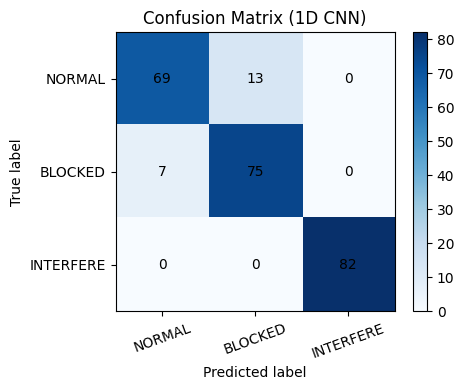

In [128]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

NUM_SAMPLES = 1

@torch.no_grad()
def predict(loader):
    model.eval()
    all_pred = []
    all_true = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)


def _mode_1d(a: np.ndarray):
    vals, counts = np.unique(a, return_counts=True)
    return vals[counts.argmax()]


def majority_vote_labels(y: np.ndarray, num_samples: int):
    if num_samples <= 1:
        return y, len(y)
    n = len(y)
    cut = n - (n % num_samples)
    if cut == 0:
        raise ValueError("NUM_SAMPLES is larger than the number of test samples.")
    if cut < n:
        print(f"Dropping {n - cut} test samples to fit NUM_SAMPLES={num_samples}")
    y = y[:cut].reshape(-1, num_samples)
    y_vote = np.apply_along_axis(_mode_1d, 1, y)
    return y_vote, cut


def majority_vote_predictions(y_pred: np.ndarray, num_samples: int, cut: int):
    if num_samples <= 1:
        return y_pred
    y_pred = y_pred[:cut].reshape(-1, num_samples)
    y_vote = np.apply_along_axis(_mode_1d, 1, y_pred)
    return y_vote


def false_positive_rate_ovr(y_true, y_pred, pos_label=OperatingCondition.BLOCKED_AIRFLOW.value):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    yt = (y_true == int(pos_label))
    yp = (y_pred == int(pos_label))
    tn = np.sum((~yt) & (~yp))
    fp = np.sum((~yt) & (yp))
    return float(fp) / (float(fp + tn) + 1e-12)

# Predict encoded labels, then decode to original label IDs
y_test_true_idx, y_test_pred_idx = predict(test_loader)
y_test_true_raw = np.array([idx_to_label[int(i)] for i in y_test_true_idx], dtype=int)
y_test_pred_raw = np.array([idx_to_label[int(i)] for i in y_test_pred_idx], dtype=int)

y_test_vote, vote_cut = majority_vote_labels(y_test_true_raw, NUM_SAMPLES)
y_pred_vote = majority_vote_predictions(y_test_pred_raw, NUM_SAMPLES, vote_cut)

acc = accuracy_score(y_test_vote, y_pred_vote)
fp = false_positive_rate_ovr(y_test_vote, y_pred_vote)

label_map = {
    OperatingCondition.NORMAL.value: "NORMAL",
    OperatingCondition.BLOCKED_AIRFLOW.value: "BLOCKED",
    OperatingCondition.BLADE_ISSUE.value: "INTERFERE",
}
labels_order = [lbl for lbl in [
    OperatingCondition.NORMAL.value,
    OperatingCondition.BLOCKED_AIRFLOW.value,
    OperatingCondition.BLADE_ISSUE.value,
] if lbl in all_labels]

print(f"1D CNN test accuracy (majority vote, NUM_SAMPLES={NUM_SAMPLES}): {acc:.3f}")
print(f"1D CNN test FP rate (NORMAL misclassified as BLOCKED): {fp:.3f}")
print()
print(classification_report(
    y_test_vote,
    y_pred_vote,
    labels=labels_order,
    target_names=[label_map.get(lbl, str(lbl)) for lbl in labels_order],
    zero_division=0,
))

cm = confusion_matrix(y_test_vote, y_pred_vote, labels=labels_order)
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (1D CNN)")
plt.colorbar()
plt.xticks(range(len(labels_order)), [label_map.get(l, str(l)) for l in labels_order], rotation=20)
plt.yticks(range(len(labels_order)), [label_map.get(l, str(l)) for l in labels_order])
plt.ylabel("True label")
plt.xlabel("Predicted label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


In [129]:
from pathlib import Path
import json
import torch

save_dir = Path("weights")
save_dir.mkdir(parents=True, exist_ok=True)
onnx_path = save_dir / "model_best_cnn1d.onnx"
meta_path = onnx_path.with_suffix(".meta.json")

model.eval()
dummy = torch.randn(1, 3, target_len, dtype=torch.float32, device=device)
with torch.no_grad():
    torch.onnx.export(
        model,
        dummy,
        onnx_path.as_posix(),
        export_params=True,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
        opset_version=18,
    )

meta = {
    "onnx_path": onnx_path.as_posix(),
    "input_shape": [1, 3, int(target_len)],
    "embedder": {
        "name": "raw1dcnn",
        "kwargs": {
            "target_len": int(target_len),
            "mean": mean.reshape(-1).astype(float).tolist(),
            "std": std.reshape(-1).astype(float).tolist(),
        },
    },
    "labels": {int(k): int(v) for k, v in idx_to_label.items()},
}
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
print(f"Saved ONNX: {onnx_path}")
print(f"Saved metadata: {meta_path}")


/tmp/ipykernel_60796/4047108524.py:13: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0311 03:45:03.309000 60796 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0311 03:45:03.584000 60796 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `Fan1DCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Fan1DCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 5 of general pattern rewrite rules.
Saved ONNX: weights/model_best_cnn1d.onnx
Saved metadata: weights/model_best_cnn1d.meta.json


In [130]:
from fdd_system.ML.common.config import SensorConfig
import torch
import numpy as np
import copy
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

WINDOW_SIZES = [400, 600, 800, 1000, 1200]
CHECK_WINDOW_SWEEP = False


NORMAL_LABEL = OperatingCondition.NORMAL.value

def fpr_normal(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    normal_mask = (y_true == int(NORMAL_LABEL))
    denom = normal_mask.sum()
    if denom == 0:
        return 0.0
    return float((y_pred[normal_mask] != int(NORMAL_LABEL)).sum()) / float(denom + 1e-12)


def run_cnn_for_window(ws):
    orig_ws = SensorConfig.WINDOW_SIZE
    orig_stride = SensorConfig.STRIDE
    SensorConfig.WINDOW_SIZE = ws
    SensorConfig.STRIDE = max(1, int(0.75 * ws))
    try:
        train_data_ws = prepare_training_data(
            train_files, True, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND
        )
        val_data_ws = prepare_training_data(
            val_files, True, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND
        )
        test_data_ws = prepare_training_data(
            test_files, False, col_names=["X", "Y", "Z"], remove_first_second=REMOVE_FIRST_SECOND
        )

        pre = StandardZNormal()
        train_pre_ws = pre.preprocess(train_data_ws)
        val_pre_ws = pre.preprocess(val_data_ws)
        test_pre_ws = pre.preprocess(test_data_ws)

        X_train_raw, y_train_raw, target_len = stack_windows(train_pre_ws)
        X_val_raw, y_val_raw, _ = stack_windows(val_pre_ws, target_len=target_len)
        X_test_raw, y_test_raw, _ = stack_windows(test_pre_ws, target_len=target_len)

        mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
        std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-6

        X_train = (X_train_raw - mean) / std
        X_val = (X_val_raw - mean) / std
        X_test = (X_test_raw - mean) / std

        all_labels = sorted(set(y_train_raw.tolist()) | set(y_val_raw.tolist()) | set(y_test_raw.tolist()))
        label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
        y_train = np.array([label_to_idx[int(y)] for y in y_train_raw], dtype=np.int64)
        y_val = np.array([label_to_idx[int(y)] for y in y_val_raw], dtype=np.int64)
        y_test = np.array([label_to_idx[int(y)] for y in y_test_raw], dtype=np.int64)

        train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
        val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
        test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = Fan1DCNN(n_classes=len(all_labels)).to(device)

        counts = np.bincount(y_train, minlength=len(all_labels)).astype(np.float32)
        class_weights = counts.sum() / np.maximum(counts * len(all_labels), 1.0)
        class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

        criterion = nn.CrossEntropyLoss(weight=class_weights_t)
        optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

        @torch.no_grad()
        def evaluate(loader):
            model.eval()
            total_loss = 0.0
            all_pred = []
            all_true = []

            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * yb.size(0)

                pred = torch.argmax(logits, dim=1)
                all_pred.append(pred.cpu().numpy())
                all_true.append(yb.cpu().numpy())

            y_true = np.concatenate(all_true)
            y_pred = np.concatenate(all_pred)
            avg_loss = total_loss / len(loader.dataset)
            acc = accuracy_score(y_true, y_pred)
            return avg_loss, acc, y_true, y_pred

        def train_one_epoch(loader):
            model.train()
            total_loss = 0.0

            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * yb.size(0)

            return total_loss / len(loader.dataset)

        best_state = None
        best_val_loss = float("inf")
        wait = 0

        for _epoch in range(1, EPOCHS + 1):
            _ = train_one_epoch(train_loader)
            val_loss, _val_acc, _, _ = evaluate(val_loader)
            scheduler.step(val_loss)

            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= EARLY_STOP_PATIENCE:
                    break

        if best_state is None:
            raise RuntimeError("Training did not produce a valid model state.")

        model.load_state_dict(best_state)
        _, val_acc, val_true, val_pred = evaluate(val_loader)
        _, test_acc, test_true, test_pred = evaluate(test_loader)

        fpr_n = fpr_normal(test_true, test_pred)

        return {
            "window_size": ws,
            "train_windows": len(train_ds),
            "val_windows": len(val_ds),
            "test_windows": len(test_ds),
            "val_acc": float(val_acc),
            "test_acc": float(test_acc),
            "fpr_normal": float(fpr_n),
        }
    finally:
        SensorConfig.WINDOW_SIZE = orig_ws
        SensorConfig.STRIDE = orig_stride


if CHECK_WINDOW_SWEEP:
    results = []
    for ws in WINDOW_SIZES:
        res = run_cnn_for_window(ws)
        results.append(res)
        print(
            f"ws={res['window_size']:4d} | train={res['train_windows']:5d} val={res['val_windows']:5d} test={res['test_windows']:5d} "
            f"| val_acc={res['val_acc']:.3f} test_acc={res['test_acc']:.3f} fpr_norm={res['fpr_normal']:.3f}"
        )

    print("Summary (val-ordered):")
    for r in results:
        print(
            f"ws={r['window_size']:4d} val_acc={r['val_acc']:.3f} test_acc={r['test_acc']:.3f} fpr_norm={r['fpr_normal']:.3f} "
            f"train={r['train_windows']} val={r['val_windows']} test={r['test_windows']}"
        )



